In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
import joblib

## 1. Load Data

In [3]:
df = pd.read_csv("../data/student_lifestyle_100k.csv")

df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [4]:
df.shape

(100000, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [6]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


In [7]:
df.isnull().sum()

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

In [8]:
# Drop ID
df.drop(columns=["Student_ID"], inplace=True)

## 2. Target Analysis

In [9]:
df["Depression"].value_counts()

Depression
False    89938
True     10062
Name: count, dtype: int64

In [10]:
# Convert target to 0/1
df["Depression"] = df["Depression"].astype(int)

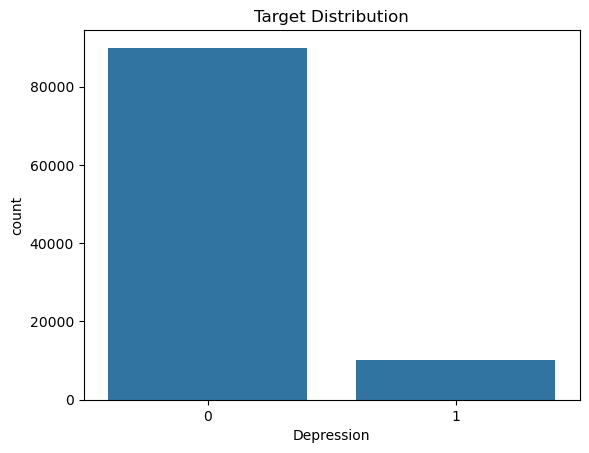

In [11]:
# Class distribution plot
sns.countplot(x="Depression", data=df)
plt.title("Target Distribution")
plt.show()

## 3. Univariate EDA

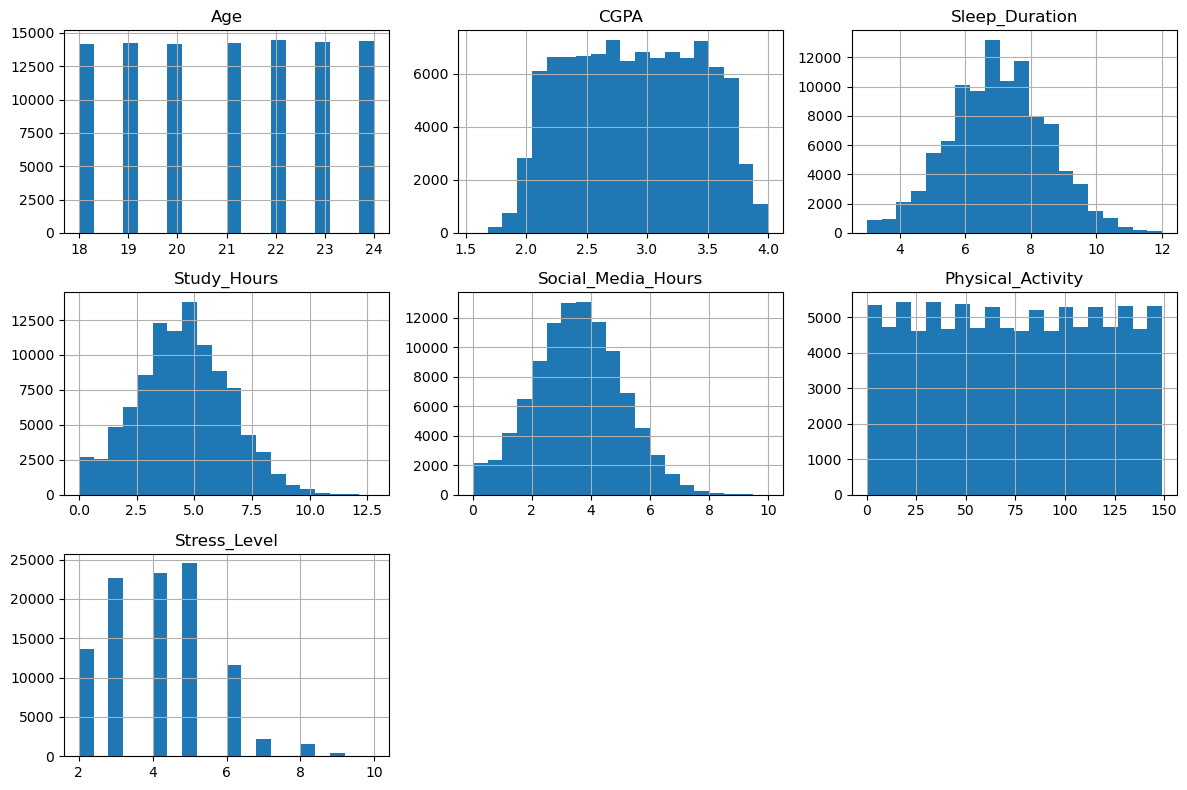

In [12]:
num_cols = ["Age","CGPA","Sleep_Duration","Study_Hours",
            "Social_Media_Hours","Physical_Activity","Stress_Level"]

df[num_cols].hist(bins=20, figsize=(12,8))
plt.tight_layout()
plt.show()

## 4.Categorical Analysis

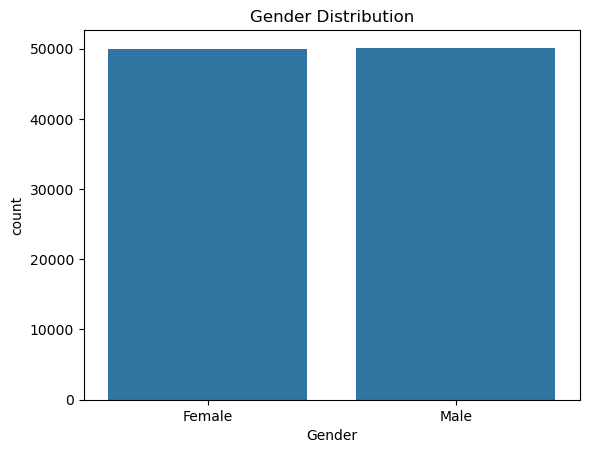

In [13]:
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

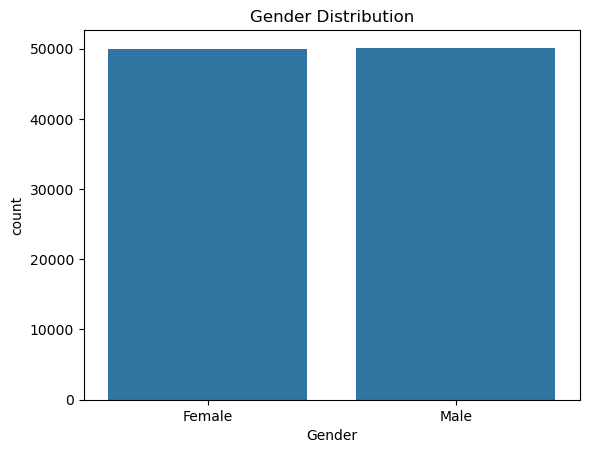

In [14]:
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

## 5 Relationship with Target

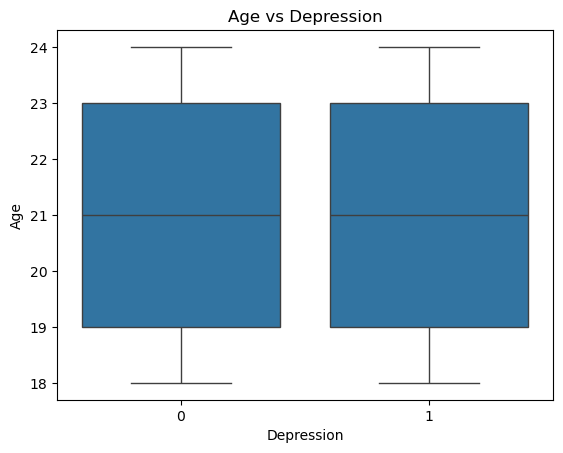

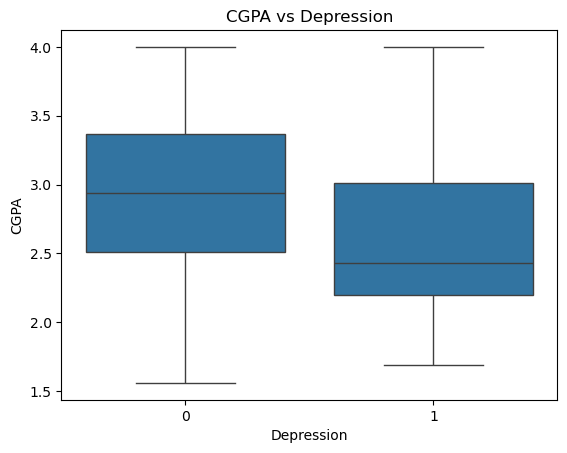

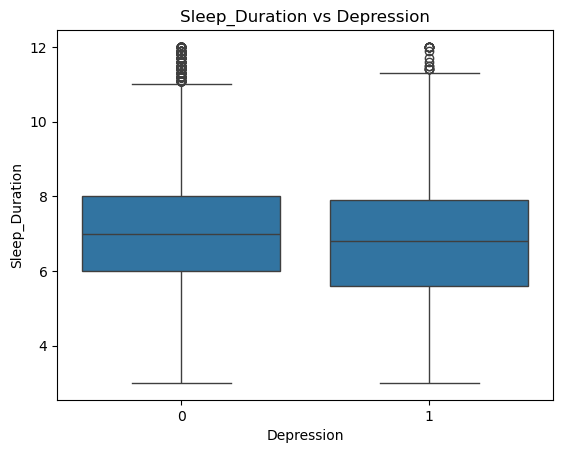

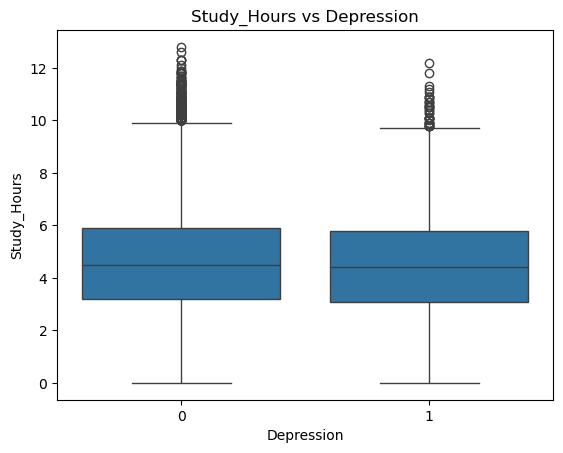

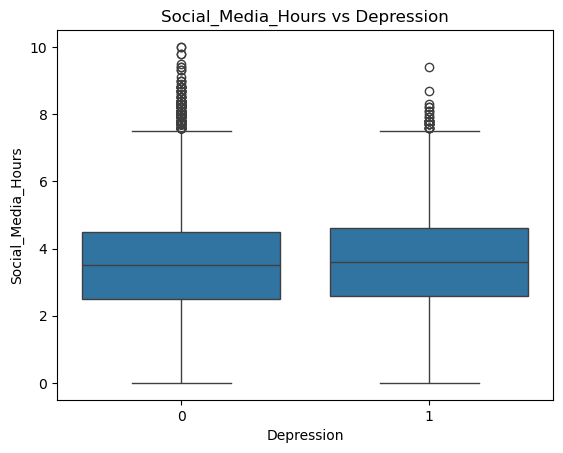

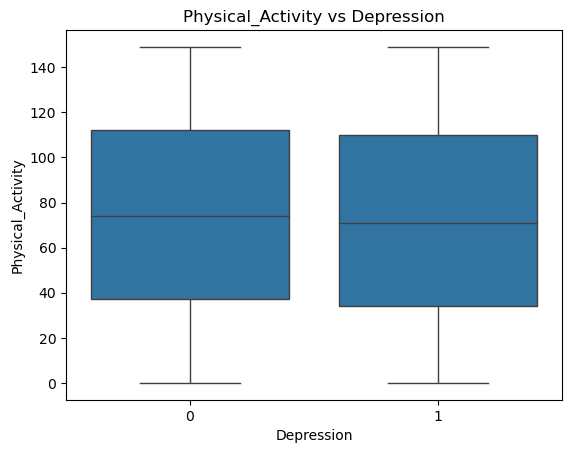

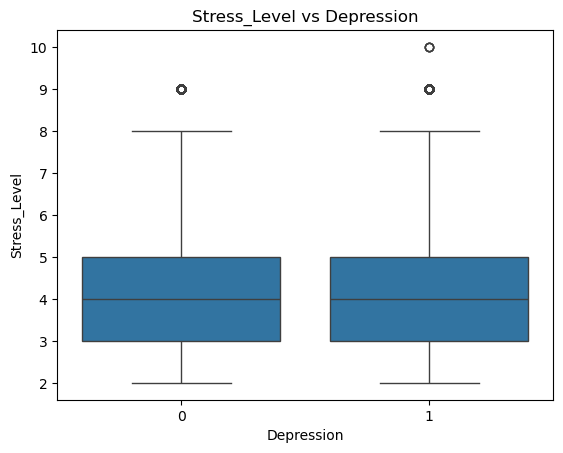

In [15]:
for col in num_cols:
    sns.boxplot(x="Depression", y=col, data=df)
    plt.title(f"{col} vs Depression")
    plt.show()

## 6 Correlation

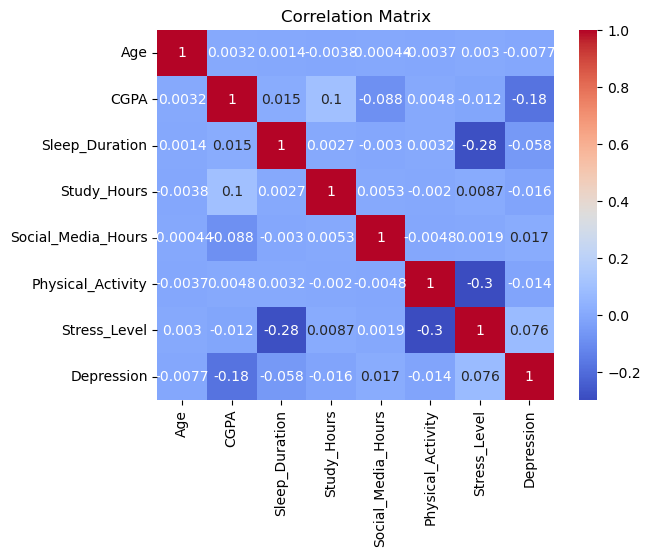

In [16]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 7 Encode Categorical

In [17]:
le_gender = LabelEncoder()
le_dept = LabelEncoder()

In [18]:
df["Gender"] = le_gender.fit_transform(df["Gender"])
df["Department"] = le_dept.fit_transform(df["Department"])

## 8. SPLIT FEATURES & TARGET

In [19]:
X = df.drop("Depression", axis=1)
y = df["Depression"]

## 9.Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 10. Scaling

In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 11. Handle Imbalance

In [22]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

After SMOTE: [71950 71950]


## 12. HYPERPARAMETER TUNING

In [23]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


## 12. Train Model

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [27]:
gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train)

GradientBoostingClassifier()

In [28]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

## 13. Evaluation

In [29]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[15750  2238]
 [ 1350   662]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     17988
           1       0.23      0.33      0.27      2012

    accuracy                           0.82     20000
   macro avg       0.57      0.60      0.58     20000
weighted avg       0.85      0.82      0.83     20000



## 15. Feature Importance

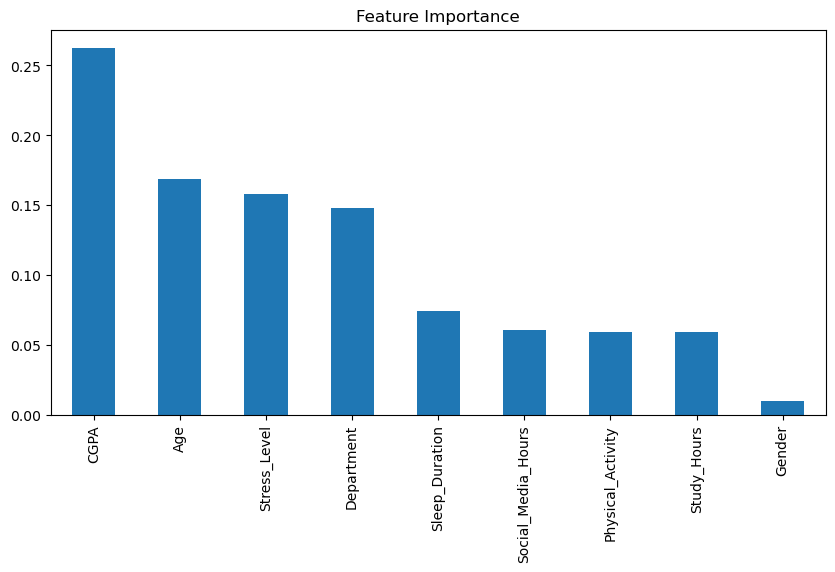

In [30]:
feature_names = X.columns

importance = pd.Series(best_model.feature_importances_, index=feature_names)
importance = importance.sort_values(ascending=False)

importance.plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance")
plt.show()

## 16. Save Model

In [31]:
feature_names = X.columns.tolist()

In [27]:
joblib.dump(best_model, "../models/depression_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(le_gender, "../models/gender_encoder.pkl")
joblib.dump(le_dept, "../models/department_encoder.pkl")
joblib.dump(feature_names, "../models/feature_names.pkl")

['../models/feature_names.pkl']